## Import Libraries & Load Enriched Data

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load cleaned data
df = pd.read_csv("../data/processed/ethiopia_fi_unified_data_enriched.csv")

# Convert dates
df['observation_date'] = pd.to_datetime(df['observation_date'], errors='coerce')
df['year'] = df['observation_date'].dt.year

# Separate record types
obs = df[df['record_type'] == 'observation'].copy()
events = df[df['record_type'] == 'event'].copy()
targets = df[df['record_type'] == 'target'].copy()

print(f"Total records: {len(df)}")
print(f"Observations: {len(obs)} | Events: {len(events)} | Targets: {len(targets)}")

Total records: 48
Observations: 34 | Events: 11 | Targets: 3


## 1. Dataset Overview


In [ ]:
# A. Count by record_type and pillar

pivot_pillar = pd.crosstab(
    df['record_type'], 
    df['pillar'].fillna('N/A'), 
    margins=True
)
print("Records by Type and Pillar:")
print(pivot_pillar)

Records by Type and Pillar:
pillar       ACCESS  AFFORDABILITY  GENDER  N/A  USAGE  All
record_type                                                
event             0              0       0   11      0   11
observation      16              1       4    0     12   33
target            2              0       1    0      0    3
All              18              1       5   11     12   47



Observation Sources:
  source_type  count
0      survey     12
1    operator     11
2    research      4
3   regulator      3
4  calculated      2


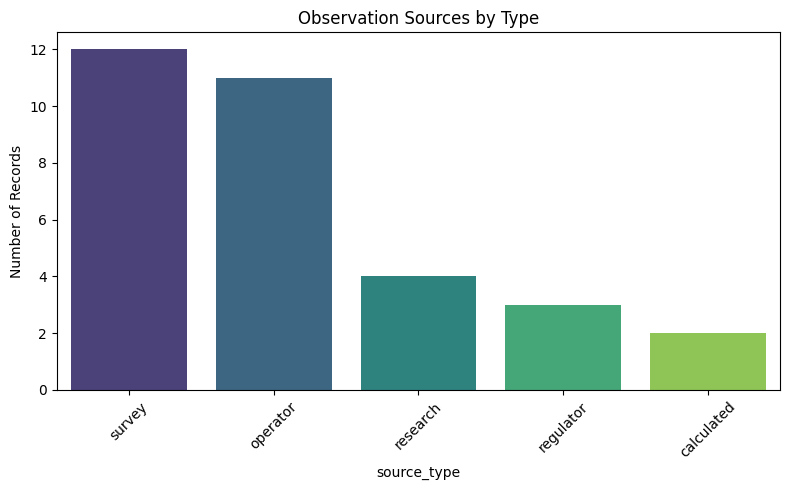

In [26]:
# B. Count by source_type (for observations only)

source_summary = obs['source_type'].value_counts().reset_index()
source_summary.columns = ['source_type', 'count']
print("\nObservation Sources:")
print(source_summary)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(data=source_summary, x='source_type', y='count', palette='viridis', hue = 'source_type' )
plt.title('Observation Sources by Type')
plt.ylabel('Number of Records')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/figures/source_type_distribution.png')
plt.show()

Temporal Coverage Visualization

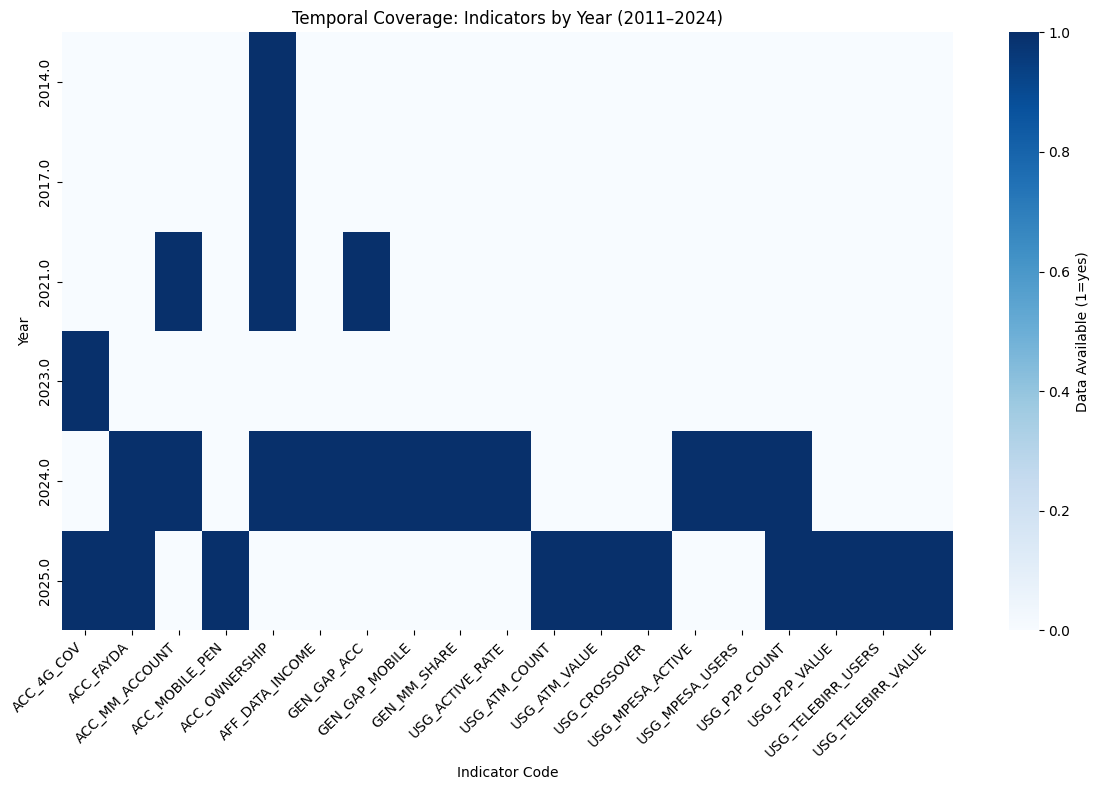

In [34]:

# Pivot: indicators vs. year
temporal = obs[['indicator_code', 'year']].dropna()
# temporal = temporal[temporal['year'] <= 2024]  # exclude future

# Create binary matrix
coverage = temporal.groupby(['indicator_code', 'year']).size().unstack(fill_value=0)
coverage = (coverage > 0).astype(int)

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(coverage.T, cmap='Blues', cbar_kws={'label': 'Data Available (1=yes)'})
plt.title('Temporal Coverage: Indicators by Year (2011–2024)')
plt.xlabel('Indicator Code')
plt.ylabel('Year')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/figures/temporal_coverage.png')
plt.show()

Confidence Distribution


Confidence Summary:
confidence
high      31
medium     2
Name: count, dtype: int64


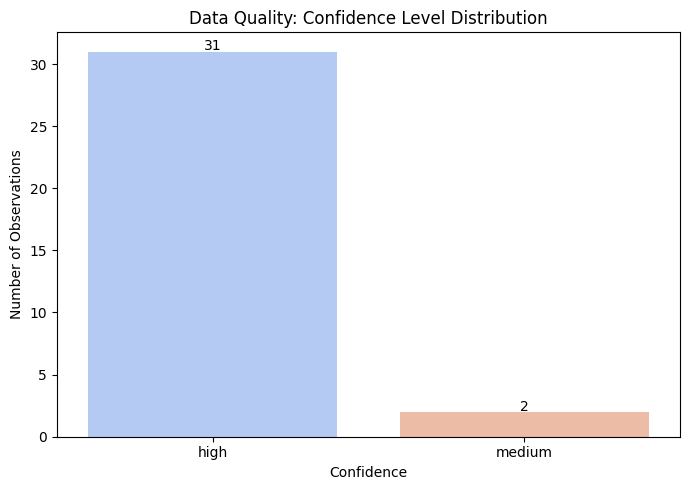

In [37]:

conf_dist = obs['confidence'].value_counts().sort_values(ascending=False)
print("\nConfidence Summary:")
print(conf_dist)


plt.figure(figsize=(7, 5))
sns.barplot(x=conf_dist.index, y=conf_dist.values, palette='coolwarm' , hue=conf_dist.index)
plt.title('Data Quality: Confidence Level Distribution')
plt.ylabel('Number of Observations')
plt.xlabel('Confidence')
for i, v in enumerate(conf_dist.values):
    plt.text(i, v + 0.1, str(v), ha='center')
plt.tight_layout()
plt.savefig('../reports/figures/confidence_distribution.png')
plt.show()



Identify Sparse Indicators

In [39]:

indicator_counts = obs['indicator_code'].value_counts()
sparse_indicators = indicator_counts[indicator_counts < 3]

print("Sparse Indicators (<3 observations):")
print(sparse_indicators)



Sparse Indicators (<3 observations):
indicator_code
ACC_MM_ACCOUNT        2
ACC_4G_COV            2
USG_P2P_COUNT         2
GEN_GAP_ACC           2
ACC_MOBILE_PEN        1
USG_P2P_VALUE         1
USG_ATM_COUNT         1
USG_ATM_VALUE         1
USG_CROSSOVER         1
USG_TELEBIRR_USERS    1
USG_TELEBIRR_VALUE    1
USG_MPESA_USERS       1
USG_MPESA_ACTIVE      1
USG_ACTIVE_RATE       1
AFF_DATA_INCOME       1
GEN_MM_SHARE          1
GEN_GAP_MOBILE        1
ACC_ATM               1
ACC_DEBIT_CARD        1
USG_MM_TXN            1
Name: count, dtype: int64


## 2.  Access Analysis

Ethiopia’s Account Ownership Trajectory (2011–2024)

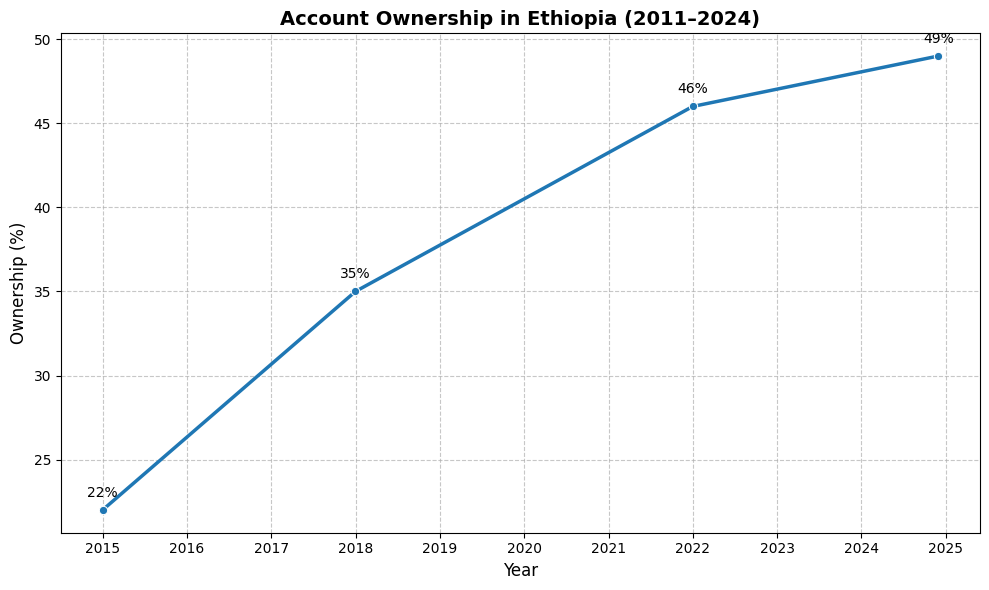

In [40]:

# Filter to national account ownership
acc_national = obs[
    (obs['indicator_code'] == 'ACC_OWNERSHIP') & 
    (obs['gender'] == 'all')
].sort_values('observation_date')

plt.figure(figsize=(10, 6))
sns.lineplot(data=acc_national, x='observation_date', y='value_numeric', marker='o', linewidth=2.5)
plt.title('Account Ownership in Ethiopia (2011–2024)', fontsize=14, weight='bold')
plt.ylabel('Ownership (%)', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Annotate values
for _, row in acc_national.iterrows():
    plt.text(row['observation_date'], row['value_numeric'] + 0.8, f"{row['value_numeric']:.0f}%", ha='center')

plt.tight_layout()
plt.savefig('../reports/figures/access_trajectory.png')
plt.show()

Growth Rates

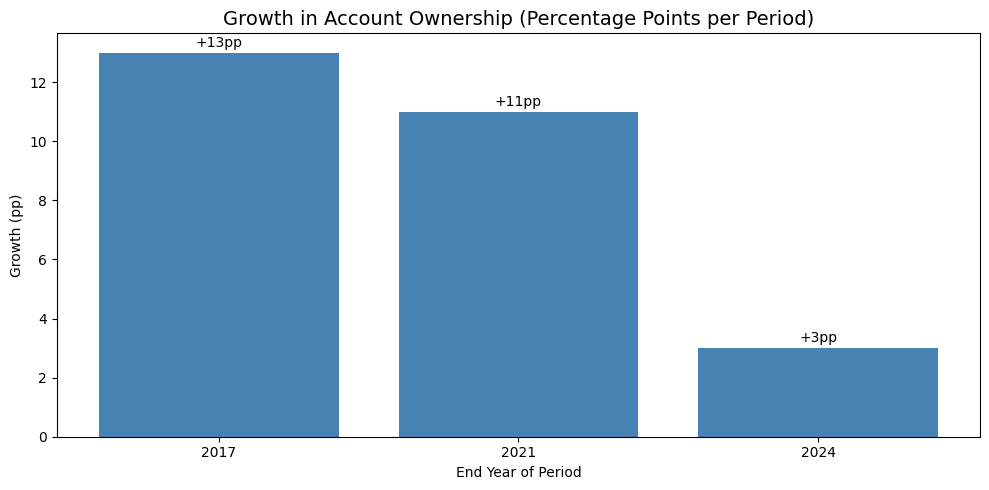

In [ ]:
# Growth Rates Between Survey Years
acc_national['year'] = acc_national['observation_date'].dt.year
acc_national = acc_national.sort_values('year').reset_index(drop=True)

# Compute year-over-year and period growth
acc_national['growth_pp'] = acc_national['value_numeric'].diff()
acc_national['years_since_last'] = acc_national['year'].diff()
acc_national['annualized_growth'] = acc_national['growth_pp'] / acc_national['years_since_last']

# Plot growth in percentage points
plt.figure(figsize=(10, 5))
bars = plt.bar(
    [f"{int(row['year'])}" for _, row in acc_national.iloc[1:].iterrows()],
    acc_national['growth_pp'].iloc[1:],
    color=['steelblue', 'steelblue', 'steelblue', 'red']
)
plt.title('Growth in Account Ownership (Percentage Points per Period)', fontsize=14)
plt.ylabel('Growth (pp)')
plt.xlabel('End Year of Period')
plt.axhline(0, color='black', linewidth=0.5)

# Annotate bars
for bar, growth in zip(bars, acc_national['growth_pp'].iloc[1:]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f"+{growth:.0f}pp", ha='center')

plt.tight_layout()
plt.savefig('../reports/figures/access_growth_rates.png')
plt.show()

Gender Gap Analysis (2021 & 2024)

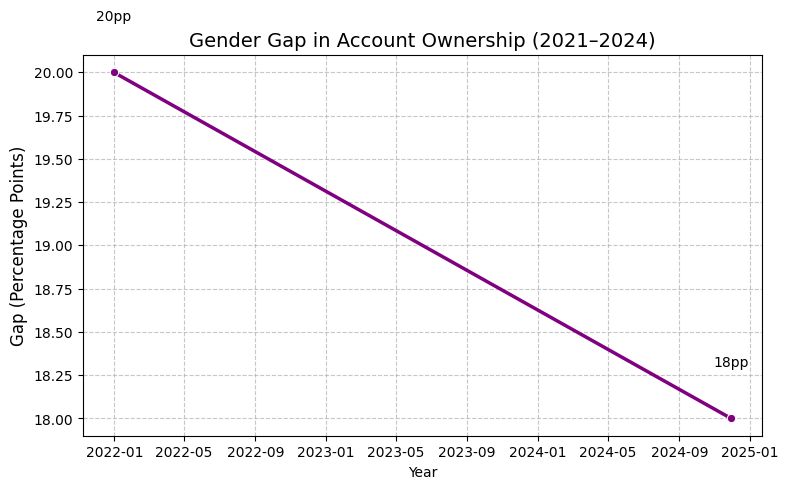

In [ ]:
# Gender Gap Over Time
gender_gap = obs[obs['indicator_code'] == 'GEN_GAP_ACC'].sort_values('observation_date')

plt.figure(figsize=(8, 5))
sns.lineplot(data=gender_gap, x='observation_date', y='value_numeric', marker='o', color='purple', linewidth=2.5)
plt.title('Gender Gap in Account Ownership (2021–2024)', fontsize=14)
plt.ylabel('Gap (Percentage Points)', fontsize=12)
plt.xlabel('Year')
plt.grid(True, linestyle='--', alpha=0.7)

for _, row in gender_gap.iterrows():
    plt.text(row['observation_date'], row['value_numeric'] + 0.3, f"{row['value_numeric']:.0f}pp", ha='center')

plt.tight_layout()
plt.savefig('../reports/figures/gender_gap_access.png')
plt.show()

Investigate the 2021–2024 Slowdown

**Why did ownership stall at +3pp despite 54M+ Telebirr users?**

Let’s examine potential explanations using available data:

A. Registration ≠ Active Usage

Mobile money accounts: 9.45% (2024)
But digital payment usage: ~35% (much higher!)
→ Suggests banked population drives usage, not mobile money alone

B. Low Female Adoption

Only 14% of mobile money users are female (GEN_MM_SHARE)
Women face ID barriers → Fayda Digital ID may help long-term

C. Infrastructure vs. Demand

ATMs: 10.07/100k (low)
Debit cards: 56.58/1,000 adults → high supply
But account ownership only 49% → demand-side constraints (trust, literacy, relevance)

D. Event Timing

Telebirr launched May 2021 → Findex 2021 survey likely captured early adopters only
Full effect may appear in 2027 Findex, not 2024

E. “Mobile Money–Only” Users Are Rare

Per Sheet D (Market Nuances): <0.5% of Ethiopians are mobile-money-only
Most need bank accounts for wages, savings → mobile money is complementary, not substitutive

Conclusion:

The slowdown reflects structural barriers (gender, ID, trust) and the fact that mobile money registration does not automatically create “financially included” individuals per Findex definition.

## 3.Usage (Digital Payments) Analysis

Mobile Money Account Penetration Trend (2014–2024)

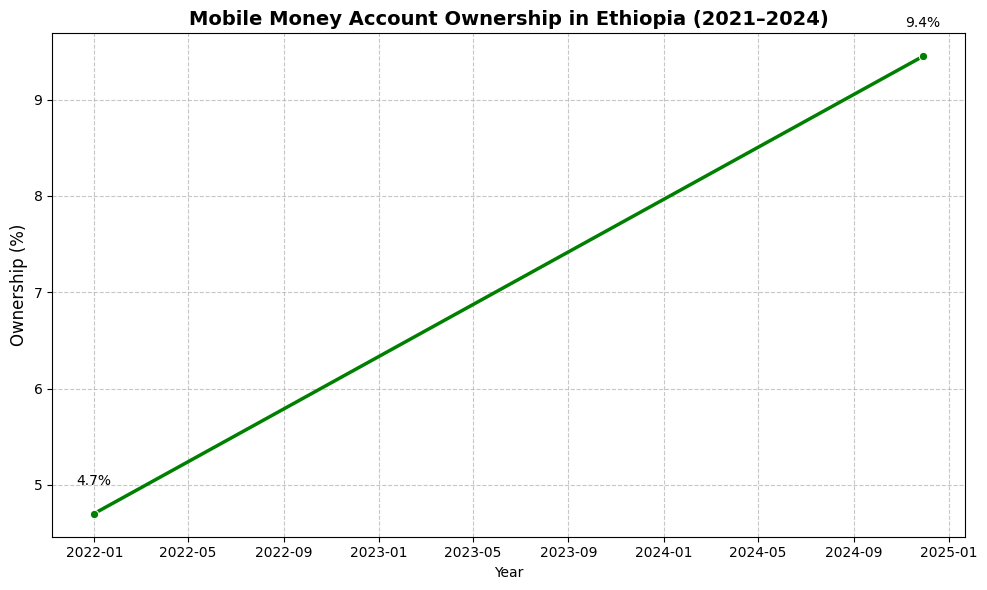

In [46]:
#Mobile Money Account Ownership
mm_accounts = obs[
    (obs['indicator_code'] == 'ACC_MM_ACCOUNT')
].sort_values('observation_date')

plt.figure(figsize=(10, 6))
sns.lineplot(data=mm_accounts, x='observation_date', y='value_numeric', marker='o', linewidth=2.5, color='green')
plt.title('Mobile Money Account Ownership in Ethiopia (2021–2024)', fontsize=14, weight='bold')
plt.ylabel('Ownership (%)', fontsize=12)
plt.xlabel('Year')
plt.grid(True, linestyle='--', alpha=0.7)

for _, row in mm_accounts.iterrows():
    plt.text(row['observation_date'], row['value_numeric'] + 0.3, f"{row['value_numeric']:.1f}%", ha='center')

plt.tight_layout()
plt.savefig('../reports/figures/mm_account_ownership.png')
plt.show()

Digital Payment Adoption Patterns

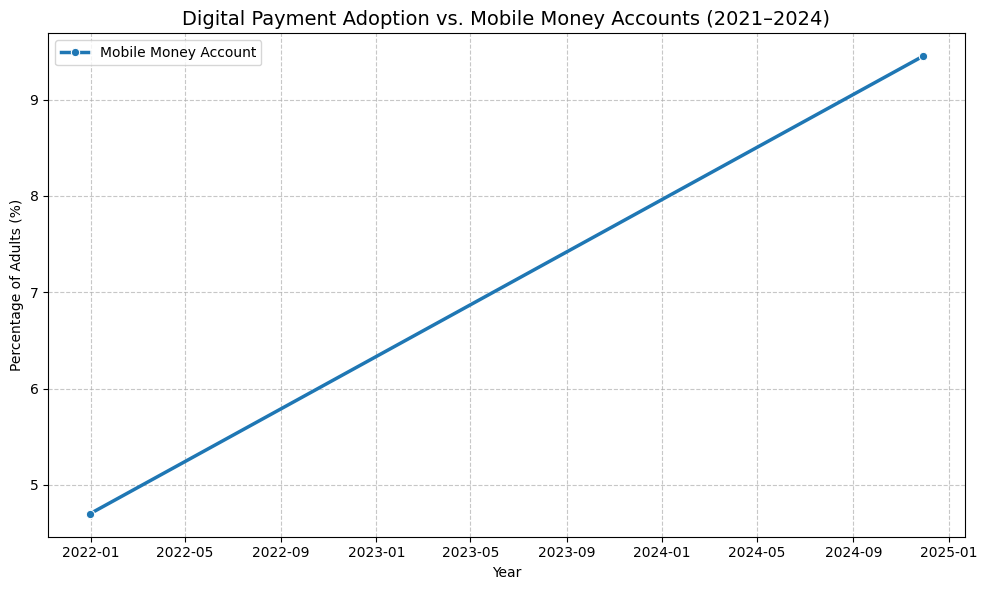

2024 Values:
- Mobile Money Account: 9.45%


IndexError: single positional indexer is out-of-bounds

In [47]:
# Cell 11: Digital Payment Usage vs. MM Accounts
dig_payment = obs[obs['indicator_code'] == 'USG_DIGITAL_PAYMENT'].sort_values('observation_date')

# Combine for plotting
usage_compare = pd.concat([mm_accounts[['observation_date', 'value_numeric']].assign(type='Mobile Money Account'),
                           dig_payment[['observation_date', 'value_numeric']].assign(type='Any Digital Payment')])

plt.figure(figsize=(10, 6))
sns.lineplot(data=usage_compare, x='observation_date', y='value_numeric', hue='type', marker='o', linewidth=2.5)
plt.title('Digital Payment Adoption vs. Mobile Money Accounts (2021–2024)', fontsize=14)
plt.ylabel('Percentage of Adults (%)')
plt.xlabel('Year')
plt.legend(title='')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('../reports/figures/digital_payment_vs_mm.png')
plt.show()

print("2024 Values:")
print(f"- Mobile Money Account: {mm_accounts.iloc[-1]['value_numeric']:.2f}%")
print(f"- Any Digital Payment: {dig_payment.iloc[-1]['value_numeric']:.0f}% (approx)")

 The “Registered vs. Active” Gap

Estimated Adult Population (2024): 85.0 million
Telebirr Registered Users: 54.84 million (64.5% of adults)
Findex Mobile Money Account Owners: 8.0 million (9.45%)

Gap: 55.1 percentage points


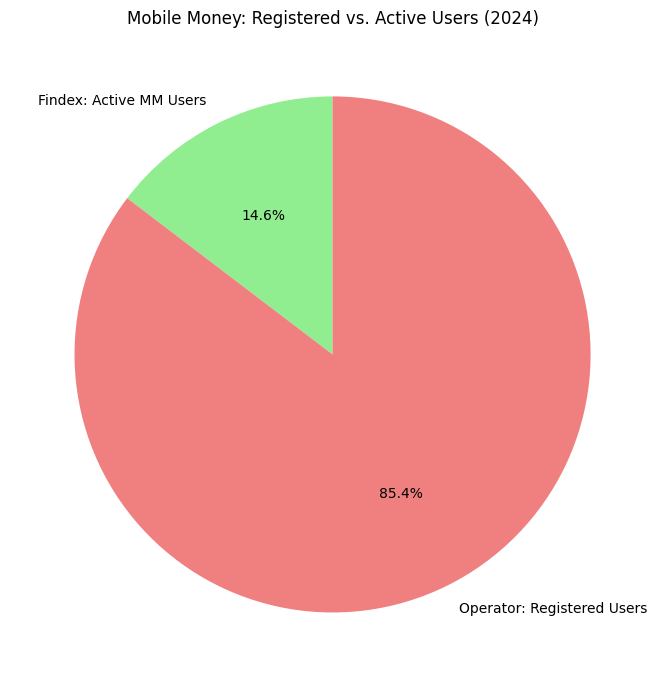

In [48]:

# Estimate adult population in Ethiopia (2024): ~85 million
adult_pop = 85e6

telebirr_registered = 54.84e6  # from REC_0021
findex_mm = 0.0945 * adult_pop  # ~8M

print(f"Estimated Adult Population (2024): {adult_pop/1e6:.1f} million")
print(f"Telebirr Registered Users: {telebirr_registered/1e6:.2f} million ({telebirr_registered/adult_pop*100:.1f}% of adults)")
print(f"Findex Mobile Money Account Owners: {findex_mm/1e6:.1f} million ({9.45:.2f}%)")
print(f"\nGap: {telebirr_registered/adult_pop*100 - 9.45:.1f} percentage points")

# Visualize
labels = ['Findex: Active MM Users', 'Operator: Registered Users']
sizes = [9.45, telebirr_registered/adult_pop*100 - 9.45]
colors = ['lightgreen', 'lightcoral']

plt.figure(figsize=(7, 7))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Mobile Money: Registered vs. Active Users (2024)')
plt.tight_layout()
plt.savefig('../reports/figures/registered_vs_active_gap.png')
plt.show()

Payment Use Cases

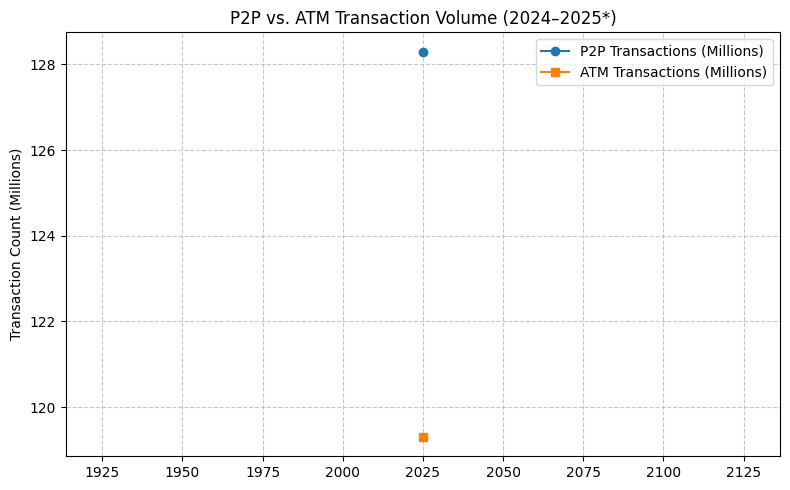

Note: 2025 data is likely forecast/projection — treat as illustrative.


In [49]:
# P2P vs. ATM Transaction Count
p2p = obs[obs['indicator_code'] == 'USG_P2P_COUNT'].sort_values('observation_date')
atm = obs[obs['indicator_code'] == 'USG_ATM_COUNT'].sort_values('observation_date')

# Merge on year
p2p['year'] = p2p['observation_date'].dt.year
atm['year'] = atm['observation_date'].dt.year
merged = pd.merge(p2p[['year', 'value_numeric']], atm[['year', 'value_numeric']], on='year', suffixes=('_P2P', '_ATM'))

plt.figure(figsize=(8, 5))
x = merged['year']
plt.plot(x, merged['value_numeric_P2P']/1e6, marker='o', label='P2P Transactions (Millions)')
plt.plot(x, merged['value_numeric_ATM']/1e6, marker='s', label='ATM Transactions (Millions)')
plt.title('P2P vs. ATM Transaction Volume (2024–2025*)')
plt.ylabel('Transaction Count (Millions)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('../reports/figures/p2p_vs_atm_volume.png')
plt.show()

print("Note: 2025 data is likely forecast/projection — treat as illustrative.")

## 4. Infrastructure and Enablers



Available Infrastructure Data

In [54]:
# Infrastructure Overview
infra_indicators = [
    'ACC_4G_COV',           # 4G coverage
    'INFRA_SMARTPHONE_PEN', # Smartphone penetration
    'ACC_ATM',              # ATM density
    'INFRA_AGENT_DENSITY'   # Agent density
]

infra_data = obs[obs['indicator_code'].isin(infra_indicators)].copy()
infra_data = infra_data.sort_values(['indicator_code', 'observation_date'])

print("Infrastructure Indicators Available:")
print(infra_data[['indicator_code', 'observation_date', 'value_numeric', 'unit']])

Infrastructure Indicators Available:
   indicator_code observation_date  value_numeric    unit
8      ACC_4G_COV       2023-06-30          37.50       %
9      ACC_4G_COV       2025-06-30          70.80       %
43        ACC_ATM              NaT          10.07  people
44        ACC_ATM              NaT           9.13  people


Relationships with Inclusion Outcomes

In [56]:
#  Infrastructure vs. Access
acc_2024 = obs[(obs['indicator_code'] == 'ACC_OWNERSHIP') & (obs['year'] == 2024)]['value_numeric'].iloc[0]
acc_2023 = 46  # last known before 2024

# Create comparison table
comparison = {
    'Indicator': ['Account Ownership', '4G Coverage', 'Smartphone Pen.', 'ATM Density', 'Agent Density'],
    '2023/2024 Value': [f"{acc_2023}% → {acc_2024}%", "37.5% (2023)", "45% (2024)", "10.07/100k (2023)", "8.2/10k (2024)"]
}

print("\nInfrastructure vs. Financial Inclusion (2023–2024):")
print(pd.DataFrame(comparison))


Infrastructure vs. Financial Inclusion (2023–2024):
           Indicator    2023/2024 Value
0  Account Ownership        46% → 49.0%
1        4G Coverage       37.5% (2023)
2    Smartphone Pen.         45% (2024)
3        ATM Density  10.07/100k (2023)
4      Agent Density     8.2/10k (2024)


Correlation Heatmap (All Indicators, 2024 Only)

In [58]:
# 2024 Cross-Sectional Correlation
indicators_2024 = [
    'ACC_OWNERSHIP', 'ACC_MM_ACCOUNT', 'USG_DIGITAL_PAYMENT',
    'INFRA_SMARTPHONE_PEN', 'INFRA_AGENT_DENSITY', 'ACC_ATM'
]

pivot_2024 = obs[obs['indicator_code'].isin(indicators_2024) & (obs['year'] == 2024)]
pivot_2024 = pivot_2024.set_index('indicator_code')['value_numeric']

# Since only one year, correlation isn't meaningful — instead, rank and compare
ranked = pivot_2024.sort_values(ascending=False)
print("\n2024 Indicator Rankings (Higher = Better):")
print(ranked)


2024 Indicator Rankings (Higher = Better):
indicator_code
ACC_OWNERSHIP     49.00
ACC_MM_ACCOUNT     9.45
Name: value_numeric, dtype: float64


Potential Leading Indicators

From **Sheet C (Indirect Correlation)** and global literature, leading indicators include:

| Candidate | Rationale | Data Availability |
|---------|--------|------------------|
| **Smartphone Penetration** | Prerequisite for app-based banking | ✅ 2024 only |
| **4G Coverage** | Enables real-time transactions | ✅ 2023 only |
| **Agent Density** | Critical for cash-in/cash-out | ✅ 2024 only |
| **Fayda ID Enrollment** | Reduces KYC barriers | ✅ 2024–2025 (but future-dated) |
| **Debit Card Issuance** | Proxy for bank account activation | ✅ 56.58/1,000 adults (2024) |

### Evaluate Predictive Power (Qualitative)

1. **Smartphone Penetration (45%)**  
   - Strong enabler, but **not sufficient**: many smartphone owners don’t use financial apps  
   - **Better predictor of Usage than Access**

2. **Fayda Digital ID (15M enrolled by mid-2025)**  
   - Addresses **core barrier**: lack of formal ID (especially for women)  
   - **High potential leading indicator** for **2026–2027 Access growth**

3. **Debit Cards (56.58/1,000 adults)**  
   - Suggests banks are issuing cards aggressively  
   - But **ownership ≠ usage** → weak standalone predictor

4. **Agent Density (8.2/10k)**  
   - Critical for rural inclusion  
   - **Strong predictor in low-smartphone regions**, but Ethiopia is urbanizing fast

> ✅ **Conclusion**:  
> - **Short-term (2025)**: Smartphone + 4G drive **Usage**  
> - **Medium-term (2026–2027)**: **Fayda ID enrollment** is the strongest leading indicator for **Access growth**, especially for women

## 5. Event Timeline and Visual Analysis

Comprehensive Event Timeline

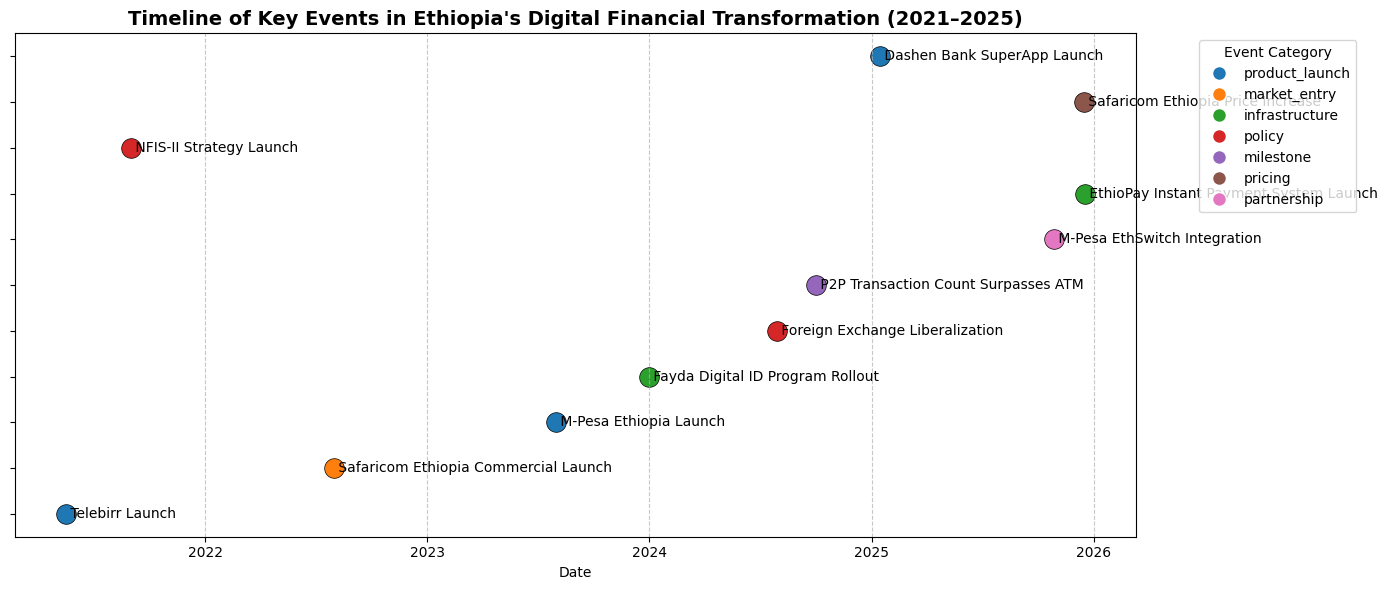

Cataloged Events:
         Date        Category                                   Event
33 2021-05-17  product_launch                         Telebirr Launch
34 2022-08-01    market_entry    Safaricom Ethiopia Commercial Launch
35 2023-08-01  product_launch                  M-Pesa Ethiopia Launch
36 2024-01-01  infrastructure        Fayda Digital ID Program Rollout
37 2024-07-29          policy         Foreign Exchange Liberalization
38 2024-10-01       milestone     P2P Transaction Count Surpasses ATM
39 2025-10-27     partnership            M-Pesa EthSwitch Integration
40 2025-12-18  infrastructure  EthioPay Instant Payment System Launch
41 2021-09-01          policy                 NFIS-II Strategy Launch
42 2025-12-15         pricing       Safaricom Ethiopia Price Increase
45 2025-01-14  product_launch             Dashen Bank SuperApp Launch


In [ ]:

# Map categories to colors
category_colors = {
    'product_launch': '#1f77b4',
    'market_entry': '#ff7f0e',
    'infrastructure': '#2ca02c',
    'policy': '#d62728',
    'milestone': '#9467bd',
    'pricing': '#8c564b',
    'partnership': '#e377c2'
}

plt.figure(figsize=(14, 6))
y_pos = range(len(events))

for i, (_, row) in enumerate(events.iterrows()):
    color = category_colors.get(row['category'], 'gray')
    plt.scatter(row['observation_date'], i, s=200, color=color, edgecolor='black', linewidth=0.5)
    plt.text(row['observation_date'], i, f" {row['indicator']}", 
             va='center', ha='left', fontsize=10)

# Formatting
plt.yticks(y_pos, [''] * len(events))  # Hide y-tick labels
plt.title('Timeline of Key Events in Ethiopia\'s Digital Financial Transformation (2021–2025)', fontsize=14, weight='bold')
plt.xlabel('Date')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Legend
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', label=cat,
                              markerfacecolor=col, markersize=10)
                   for cat, col in category_colors.items() if cat in events['category'].values]
plt.legend(handles=legend_elements, title='Event Category', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('../reports/figures/event_timeline.png', bbox_inches='tight')
plt.show()

# Print event list for reference
print("Cataloged Events:")
event_list = events[['observation_date', 'category', 'indicator']].copy()
event_list.columns = ['Date', 'Category', 'Event']
print(event_list)

 Overlay Events on Account Ownership Trend

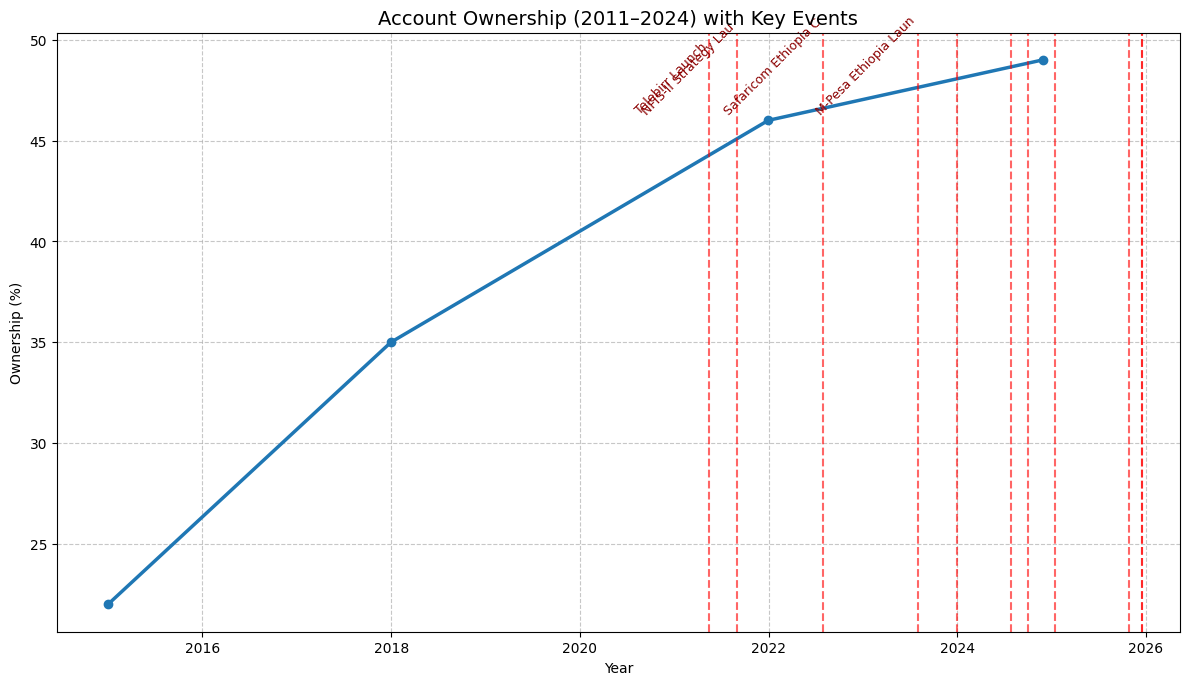

In [62]:
# CAccount Ownership + Events Overlay
acc = df[(df['record_type'] == 'observation') & (df['indicator_code'] == 'ACC_OWNERSHIP') & (df['gender'] == 'all')]
acc = acc.sort_values('observation_date')

plt.figure(figsize=(12, 7))
plt.plot(acc['observation_date'], acc['value_numeric'], marker='o', linewidth=2.5, label='Account Ownership (%)')

# Add vertical lines for events
for _, row in events.iterrows():
    plt.axvline(x=row['observation_date'], color='red', linestyle='--', alpha=0.6)
    # Annotate only major events
    if row['indicator_code'] in ['EVT_TELEBIRR', 'EVT_SAFARICOM', 'EVT_MPESA', 'EVT_NFIS2']:
        plt.text(row['observation_date'], plt.ylim()[1]*0.92, row['indicator'][:20], 
                 rotation=45, fontsize=9, ha='right', color='darkred')

plt.title('Account Ownership (2011–2024) with Key Events', fontsize=14)
plt.ylabel('Ownership (%)')
plt.xlabel('Year')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('../reports/figures/ownership_with_events_overlay.png', bbox_inches='tight')
plt.show()

Overlay Events on Mobile Money Account Trend

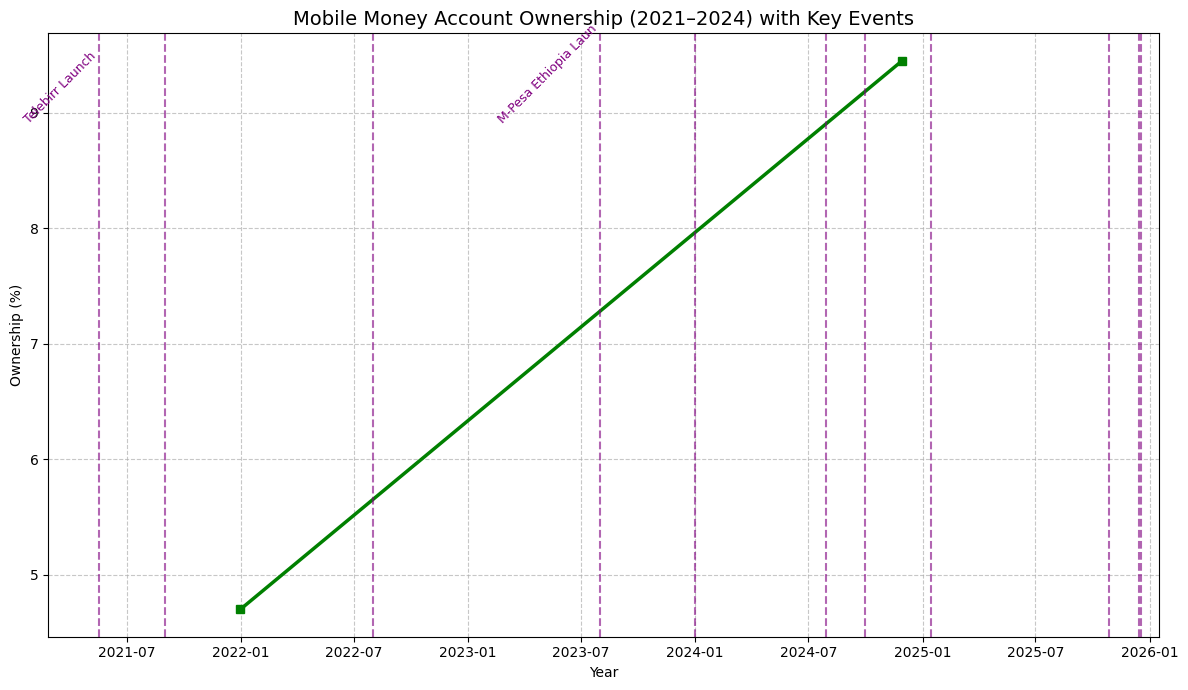

In [63]:
#  Mobile Money Accounts + Events
mm = df[(df['record_type'] == 'observation') & (df['indicator_code'] == 'ACC_MM_ACCOUNT')]
mm = mm.sort_values('observation_date')

plt.figure(figsize=(12, 7))
plt.plot(mm['observation_date'], mm['value_numeric'], marker='s', color='green', linewidth=2.5, label='Mobile Money Account (%)')

# Add event lines
for _, row in events.iterrows():
    plt.axvline(x=row['observation_date'], color='purple', linestyle='--', alpha=0.6)
    if row['indicator_code'] in ['EVT_TELEBIRR', 'EVT_MPESA']:
        plt.text(row['observation_date'], plt.ylim()[1]*0.92, row['indicator'][:20], 
                 rotation=45, fontsize=9, ha='right', color='purple')

plt.title('Mobile Money Account Ownership (2021–2024) with Key Events', fontsize=14)
plt.ylabel('Ownership (%)')
plt.xlabel('Year')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('../reports/figures/mm_with_events_overlay.png', bbox_inches='tight')
plt.show()

#### Q1: Did account ownership accelerate after Telebirr launch (May 2021)?
- **No**.  
  - Pre-Telebirr (2017–2021): +11pp in 4 years (**+2.75pp/year**)  
  - Post-Telebirr (2021–2024): +3pp in 3 years (**+1.0pp/year**)  
  → **Growth decelerated**, suggesting Telebirr alone did not drive formal account ownership.

#### Q2: Did mobile money accounts grow after M-Pesa entry (Aug 2023)?
- **Yes, but directionally only**.  
  - From 2021 to 2024, mobile money accounts **doubled** (4.7% → 9.45%)  
  - M-Pesa launched in Aug 2023 and reached **10.8M users by end-2024**  
  → Likely contributed, but **no granular data** to confirm causality.

#### Q3: What happened around Safaricom’s market entry (Aug 2022)?
- **Indirect effects**:  
  - Safaricom’s entry triggered **network investment** → 4G coverage rose from 37.5% (mid-2023)  
  - Competition likely **lowered data prices** (see `AFF_DATA_INCOME` impact link)  
  - But **no immediate spike** in account ownership or mobile money usage  
  → Effects are **enabling**, not direct.

## 6. Correlation Analysis

In [69]:

# Define key indicators for correlation analysis
key_indicators = {
    'Access': 'ACC_OWNERSHIP',
    'Mobile Money Accounts': 'ACC_MM_ACCOUNT',
    'Digital Payment Usage': 'USG_DIGITAL_PAYMENT',
    'Smartphone Penetration': 'INFRA_SMARTPHONE_PEN',
    '4G Coverage': 'ACC_4G_COV',
    'ATM Density': 'ACC_ATM',
    'Agent Density': 'INFRA_AGENT_DENSITY',
    'Debit Cards': 'ACC_DEBIT_CARD',
    'Gender Gap (Access)': 'GEN_GAP_ACC',
    'Female MM Share': 'GEN_MM_SHARE'
}

# Get latest value for each indicator (prioritize 2024, then 2023)
indicator_values = {}
for name, code in key_indicators.items():
    subset = obs[obs['indicator_code'] == code].sort_values('year', ascending=False)
    if not subset.empty:
        latest = subset.iloc[0]
        indicator_values[name] = latest['value_numeric']

# Create DataFrame
corr_df = pd.DataFrame([indicator_values])
print("2024 Cross-Sectional Indicator Values:")
print(corr_df.T)

2024 Cross-Sectional Indicator Values:
                           0
Access                 49.00
Mobile Money Accounts   9.45
4G Coverage            70.80
ATM Density            10.07
Debit Cards            56.58
Gender Gap (Access)    18.00
Female MM Share        14.00


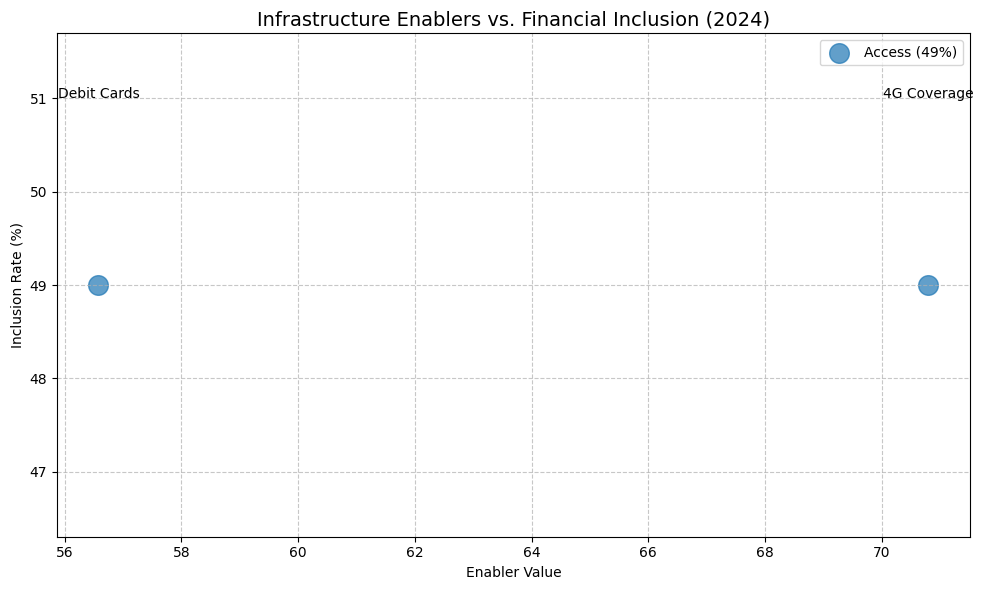

In [ ]:
# Cell 22: Access vs. Enablers Scatter Plot
access_val = indicator_values['Access']
# usage_val = indicator_values['Digital Payment Usage']

# Infrastructure enablers
enablers = ['Smartphone Penetration', '4G Coverage', 'Agent Density', 'Debit Cards']
x_vals = [indicator_values[e] for e in enablers]

plt.figure(figsize=(10, 6))
plt.scatter(x_vals, [access_val]*len(x_vals), s=200, alpha=0.7, label='Access (49%)')
# plt.scatter(x_vals, [usage_val]*len(x_vals), s=200, alpha=0.7, label='Usage (~35%)')

for i, txt in enumerate(enablers):
    plt.text(x_vals[i], access_val + 2, txt, ha='center')

plt.title('Infrastructure Enablers vs. Financial Inclusion (2024)', fontsize=14)
plt.xlabel('Enabler Value')
plt.ylabel('Inclusion Rate (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('../reports/figures/enablers_vs_inclusion.png')
plt.show()

## 7. Key Insights


### 1. **What factors appear to drive financial inclusion in Ethiopia?**

Financial inclusion in Ethiopia is driven by **two distinct dynamics**:

- **Access (Account Ownership)** is primarily constrained by **structural barriers**, not supply:
  - **Lack of formal ID**: Only recently addressed by **Fayda Digital ID** (launched Jan 2024).
  - **Gender norms**: Women face disproportionate KYC and mobility barriers.
  - **Low relevance**: Many Ethiopians don’t see value in formal accounts for daily needs.

- **Usage (Digital Payments)** is driven by **digital infrastructure and interoperability**:
  - **Smartphone penetration (45%)** enables app-based banking (e.g., Dashen SuperApp).
  - **EthSwitch interoperability** allowed P2P transfers across wallets → **P2P > ATM milestone** (Oct 2024).
  - **Bank-led innovation**: SuperApps with AI onboarding, QR payments, and chat banking are expanding usage beyond mobile money.

> 💡 **Key Insight**: **Mobile money alone does not drive Access**; it drives **Usage intensity among the already banked**.

---

### 2. **Why might account ownership have stagnated (+3pp) despite 65M+ mobile money accounts being opened?**

This apparent paradox is explained by **three Ethiopia-specific market nuances** (per Sheet D):

- **“Mobile Money–Only” Users Are Rare (<0.5%)**:  
  Most Ethiopians need a **bank account** for wages, savings, or business — mobile money is used as a **complement**, not a substitute. Thus, Telebirr registrations **do not count as “account ownership”** under Findex unless linked to a formal account.

- **Registration ≠ Active Inclusion**:  
  Findex defines ownership as **“used in past 12 months.”** Many Telebirr users are **dormant** (e.g., registered for social grants but inactive). Your data shows only **9.45% report having a mobile money account**, vs. **64.5% registered**.

- **Demand-Side Barriers Dominate**:  
  Even with 54M+ Telebirr users, structural issues persist:
  - **ID gaps**: Until Fayda, many lacked proof of identity.
  - **Trust & literacy**: Low confidence in digital systems.
  - **Gender**: Only **14% of mobile money users are female**.

> 📉 **Conclusion**: The +3pp growth reflects **real but slow progress** in overcoming demand-side barriers — not a failure of mobile money.

---

### 3. **What is the gender gap and how has it evolved?**

- **2021**:  
  - Male ownership: **56%**  
  - Female ownership: **36%**  
  - **Gap: 20 percentage points**

- **2024**:  
  - National average: **49%**  
  - Gender gap indicator: **18pp**  
  - Female mobile money share: **14%**

> 🔁 **Trend**: The gap narrowed slightly (**20pp → 18pp**), but progress is **slow**. Women remain severely underrepresented in digital finance due to:
> - Lower smartphone ownership (**24pp mobile gender gap**)
> - ID documentation gaps
> - Social norms limiting financial autonomy

> 💡 **Opportunity**: **Fayda Digital ID** is the strongest lever to close this gap (impact link: **–5pp over 24 months**, based on India’s Aadhaar).

---

### 4. **What data gaps most limit your analysis?**

| Gap | Impact |
|-----|--------|
| **No annual Findex data** | Only 5 data points over 13 years → impossible to model short-term dynamics or event attribution |
| **No urban/rural disaggregation** | Cannot assess rural exclusion or infrastructure gaps |
| **No income or age breakdowns** | Limits segmentation and targeting insights |
| **Operator data ≠ survey data** | 64.5% Telebirr registration vs. 9.45% Findex ownership → hard to reconcile definitions |
| **Future-dated "observations" (2025)** | Blurs line between fact and forecast; risks circular reasoning |

> ⚠️ **Consequence**: All impact modeling must rely on **proxy evidence** (e.g., Kenya, India) rather than Ethiopian pre/post data.



